# M2 — Comparing the four plant models, and choosing one for the collar

**Project:** Bio-Inspired Medicinal Plant Species Crowd-sourcing Using Goats
**Course:** CSC 3118 — Computer Science Project I

The four plant models were trained independently, from scratch, in their own
notebooks. Each made the same split with the same seed; this notebook checks
that their **split IDs match** before comparing anything.

It then:

1. Collects the four results into one table.
2. **Merges the two neem folders** (`nim_bg`, `nim_2_bg`) into one species and
   re-scores every model on the **real plant species**.
3. Shows per-species scores and confusion matrices.
4. Puts **confidence intervals** on the scores, by resampling test leaf groups.
5. Plots accuracy against size and speed.
6. Applies a **stated selection rule** and names the model for the collar.

It reads only the files the four notebooks saved in `plant_results/results/`.
Nothing is retrained. It runs in under a minute.

**Run order:** Kernel → Restart Kernel and Run All Cells, from the same folder as
the four plant notebooks.

In [1]:
# =============================================================================
# CONFIGURATION
# =============================================================================
OUT_DIR = "plant_results"

TAGS = ["M2_1_SimpleCNN", "M2_2_ResNet18", "M2_3_MobileNetV2", "M2_4_EfficientNetB0"]

# Folders that hold the SAME species. Their probabilities are added together
# and they are scored as one plant. "nim" is neem.
MERGE = {"nim_bg": "neem", "nim_2_bg": "neem"}

# Readable names for the report. Edit the right-hand side if a folder name
# doesn't say which plant it is (for example the folder called "1").
RENAME = {"1": "folder 1", "aloe_vera_bg": "aloe vera", "moringa_bg": "moringa",
          "tulsi_bg": "tulsi", "neem": "neem"}

N_BOOTSTRAP = 1000
RANDOM_SEED = 42

# One fixed colour per model, the same in every figure (colour-blind-safe order).
MODEL_COLORS = {"Simple CNN": "#2a78d6", "ResNet-18": "#eb6834",
                "MobileNetV2": "#1baf7a", "EfficientNet-B0": "#eda100"}
MODEL_MARKERS = {"Simple CNN": "o", "ResNet-18": "s", "MobileNetV2": "^", "EfficientNet-B0": "D"}

In [2]:
# =============================================================================
# IMPORTS
# =============================================================================
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

RESULTS_DIR = os.path.join(OUT_DIR, "results")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 10,
})
INK, MUTED = "#1f2933", "#9aa5b1"
rng = np.random.default_rng(RANDOM_SEED)

## Step 1 — Load the four results and check they used the same split

In [3]:
# =============================================================================
# LOAD RESULTS AND PER-PHOTO TEST PROBABILITIES
# =============================================================================
R, P = {}, {}
for tag in TAGS:
    jp = os.path.join(RESULTS_DIR, f"{tag}.json")
    npz = os.path.join(RESULTS_DIR, f"{tag}_test_probs.npz")
    for f in (jp, npz):
        if not os.path.exists(f):
            raise FileNotFoundError(f"Missing {f}. Run the {tag} notebook first, from this folder.")
    r = json.load(open(jp))
    R[r["model"]] = r
    P[r["model"]] = np.load(npz, allow_pickle=True)
MODELS = list(R)

ids = {m: R[m].get("split_id") for m in MODELS}
print("Split IDs:", ids)
if len(set(ids.values())) != 1:
    raise ValueError("The four notebooks did NOT use the same split (different split IDs). "
                     "Re-run them with exactly the same DATA_DIR before comparing.")

first = P[MODELS[0]]
FOLDERS = [str(c) for c in first["classes"]]
y_te = first["y"].astype(int)
groups = first["groups"].astype(str)
for m in MODELS:
    assert np.array_equal(P[m]["y"], first["y"]), f"{m}: test photos differ"
print(f"\nSame split in all four. Test set: {len(y_te)} photos, {len(np.unique(groups))} leaf groups")
print("Test photos per folder:")
print(pd.Series(np.bincount(y_te, minlength=len(FOLDERS)), index=FOLDERS).to_string())

Split IDs: {'Simple CNN': '2ee04fb978', 'ResNet-18': '2ee04fb978', 'MobileNetV2': '2ee04fb978', 'EfficientNet-B0': '2ee04fb978'}

Same split in all four. Test set: 332 photos, 273 leaf groups
Test photos per folder:
1               123
aloe_vera_bg      2
moringa_bg       55
nim_2_bg         85
nim_bg            9
tulsi_bg         58


### Why the test counts matter

Look at the smallest counts above. A plant with only a handful of test photos
can swing its F1 score from 1.0 to 0.8 on **one** photo, and macro F1 averages
every plant equally. So small differences in macro F1 between models may be
noise. Step 4 measures exactly how much.

In [4]:
# =============================================================================
# TABLE: THE FOUR MODELS AS TRAINED (one class per folder)
# =============================================================================
table = pd.DataFrame({m: {
    "Accuracy": r["test"]["accuracy"],
    "Macro F1 (per folder)": r["test"]["macro_f1"],
    "Top-2 accuracy": r["test"]["top2_accuracy"],
    "Macro ROC-AUC": r["test"]["macro_roc_auc"],
    "Reject theta": r["reject_option"]["theta"],
    "Coverage at theta": r["reject_option"]["test_coverage"],
    "Weights": r["parameters"],
    "INT8 size (MB)": r["int8_estimate_mb"],
    "ms per photo (laptop)": r["ms_per_image"],
    "Epochs (best)": f'{r["epochs_run"]} ({r["best_epoch"]})',
    "Training time (min)": round(r["train_seconds"] / 60, 1),
} for m, r in R.items()})
table

,Simple CNN,ResNet-18,MobileNetV2,EfficientNet-B0
Accuracy,0.978916,0.966867,0.966867,0.96988
Macro F1 (per folder),0.925993,0.90829,0.911621,0.955983
Top-2 accuracy,1.0,1.0,0.996988,0.996988
Macro ROC-AUC,0.999149,0.999357,0.998732,0.998068
Reject theta,0.2,0.73,0.57,0.2
Coverage at theta,1.0,0.972892,0.993976,1.0
Weights,391398,11189190,2265670,4057250
INT8 size (MB),0.391,11.189,2.266,4.057
ms per photo (laptop),9.4,32.87,20.54,23.76
Epochs (best),39 (29),51 (41),31 (21),32 (22)


## Step 2 — Score on real species: merge the two neem folders

The dataset stores neem in **two folders** (`nim_bg` and `nim_2_bg`). The models
learned them as two separate classes, so a neem leaf called "the other neem"
counted as a mistake. For the collar, both answers mean *neem*.

We add each model's two neem probabilities together and score on species. This
is a fair post-hoc merge: it uses the same trained models and the same test
photos, and changes only what counts as a correct answer.

In [5]:
# =============================================================================
# MERGE FOLDERS INTO SPECIES
# =============================================================================
species_of = {f: MERGE.get(f, f) for f in FOLDERS}
SPECIES = sorted(set(species_of.values()))
col_to_sp = np.array([SPECIES.index(species_of[f]) for f in FOLDERS])
NAMES = [RENAME.get(s, s.replace("_bg", "").replace("_", " ")) for s in SPECIES]

ys = col_to_sp[y_te]                                   # species label of every test photo
PS = {}
for m in MODELS:
    pr = P[m]["probs"]
    PS[m] = np.stack([pr[:, col_to_sp == j].sum(1) for j in range(len(SPECIES))], axis=1)

merged_note = {sp: [f for f in FOLDERS if species_of[f] == sp] for sp in SPECIES}
print("Species and the folders they come from:")
for sp, n in zip(SPECIES, NAMES):
    print(f"  {n:<22} <- {merged_note[sp]}")


def species_scores(p, y):
    pred = p.argmax(1)
    labs = np.unique(y)
    return {"accuracy": accuracy_score(y, pred),
            "macro_f1": f1_score(y, pred, labels=labs, average="macro", zero_division=0)}


rows = []
for m in MODELS:
    s = species_scores(PS[m], ys)
    rows.append({"model": m,
                 "Accuracy (per folder)": R[m]["test"]["accuracy"],
                 "Accuracy (species)": s["accuracy"],
                 "Macro F1 (per folder)": R[m]["test"]["macro_f1"],
                 "Macro F1 (species)": s["macro_f1"]})
species_table = pd.DataFrame(rows).set_index("model")
species_table.to_csv(os.path.join(RESULTS_DIR, "M2_species_scores.csv"))
species_table.round(4)

Species and the folders they come from:
  folder 1               <- ['1']
  aloe vera              <- ['aloe_vera_bg']
  moringa                <- ['moringa_bg']
  neem                   <- ['nim_2_bg', 'nim_bg']
  tulsi                  <- ['tulsi_bg']


,Accuracy (per folder),Accuracy (species),Macro F1 (per folder),Macro F1 (species)
model,,,,
Simple CNN,0.9789,0.9910,0.9260,0.9527
ResNet-18,0.9669,0.9849,0.9083,0.9480
MobileNetV2,0.9669,0.9789,0.9116,0.9421
EfficientNet-B0,0.9699,0.9789,0.9560,0.9800


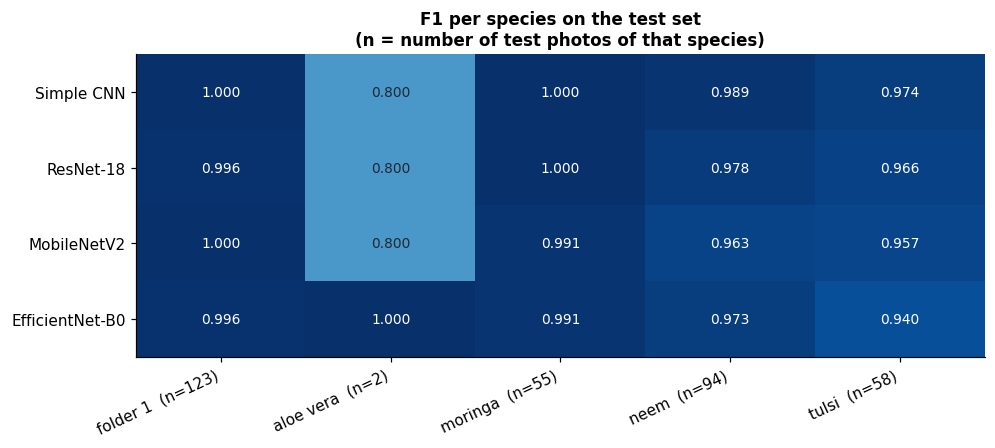

,folder 1 (n=123),aloe vera (n=2),moringa (n=55),neem (n=94),tulsi (n=58)
Simple CNN,1.000,0.8,1.000,0.989,0.974
ResNet-18,0.996,0.8,1.000,0.978,0.966
MobileNetV2,1.000,0.8,0.991,0.963,0.957
EfficientNet-B0,0.996,1.0,0.991,0.973,0.940


In [6]:
# =============================================================================
# PER-SPECIES F1 FOR EVERY MODEL  (heatmap)
# =============================================================================
test_n = np.bincount(ys, minlength=len(SPECIES))
per = pd.DataFrame({m: f1_score(ys, PS[m].argmax(1), labels=range(len(SPECIES)),
                                average=None, zero_division=0) for m in MODELS},
                   index=[f"{n}  (n={k})" for n, k in zip(NAMES, test_n)]).T

fig, ax = plt.subplots(figsize=(1.35 * len(SPECIES) + 2.4, 0.62 * len(MODELS) + 1.7))
ax.imshow(per.values, cmap="Blues", vmin=0.5, vmax=1.0, aspect="auto")
ax.grid(False)
ax.set_xticks(range(per.shape[1]), per.columns, rotation=25, ha="right")
ax.set_yticks(range(per.shape[0]), per.index)
for i in range(per.shape[0]):
    for j in range(per.shape[1]):
        v = per.values[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=9,
                color="white" if v > 0.85 else INK)
ax.set_title("F1 per species on the test set\n(n = number of test photos of that species)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "M2_compare_per_species_f1.png"))
plt.show()
per.round(3)

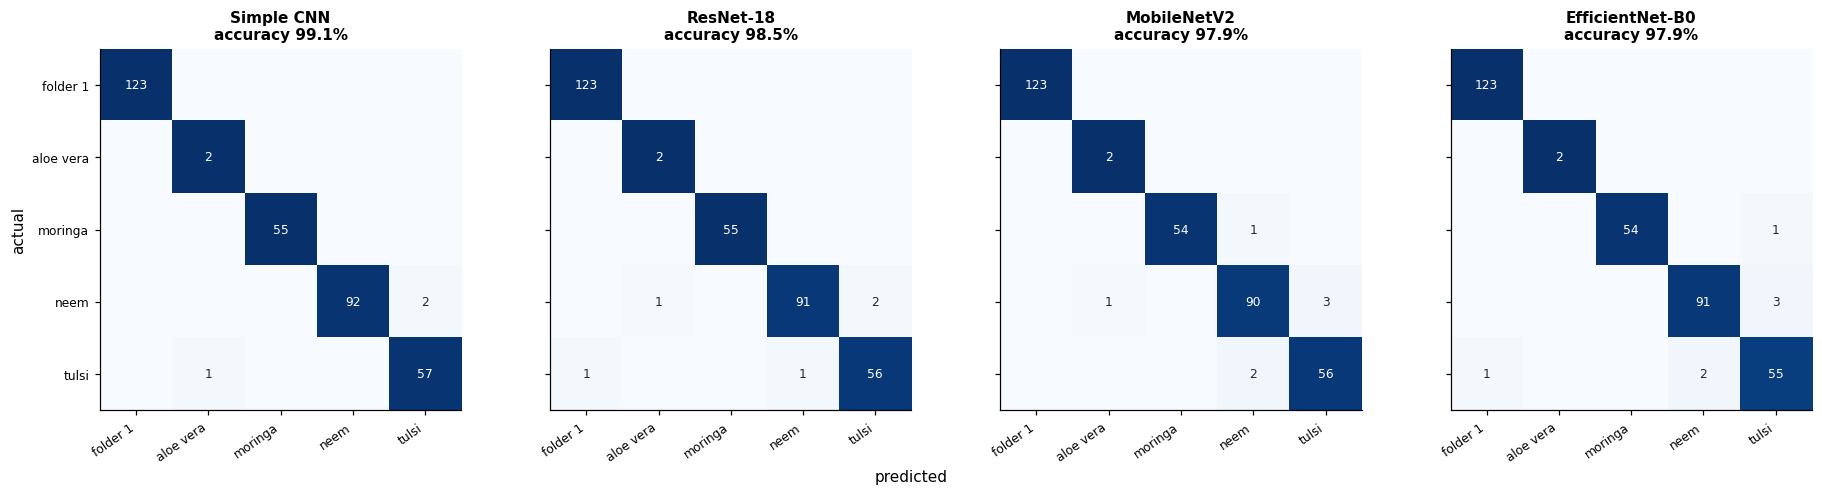

In [7]:
# =============================================================================
# CONFUSION MATRICES (species), one per model
# =============================================================================
fig, axes = plt.subplots(1, len(MODELS), figsize=(4.3 * len(MODELS), 4.3))
for ax, m in zip(axes, MODELS):
    cm = confusion_matrix(ys, PS[m].argmax(1), labels=range(len(SPECIES)))
    pct = cm / cm.sum(1, keepdims=True).clip(min=1) * 100
    ax.imshow(pct, cmap="Blues", vmin=0, vmax=100); ax.grid(False)
    ax.set_xticks(range(len(SPECIES)), NAMES, rotation=35, ha="right", fontsize=8)
    ax.set_yticks(range(len(SPECIES)), NAMES if ax is axes[0] else [""] * len(SPECIES), fontsize=8)
    for i in range(len(SPECIES)):
        for j in range(len(SPECIES)):
            if cm[i, j]:
                ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8,
                        color="white" if pct[i, j] > 55 else INK)
    ax.set_title(f"{m}\naccuracy {accuracy_score(ys, PS[m].argmax(1)):.1%}", fontsize=10)
axes[0].set_ylabel("actual")
fig.supxlabel("predicted", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "M2_compare_confusion_species.png"))
plt.show()

## Step 3 — The headline scores

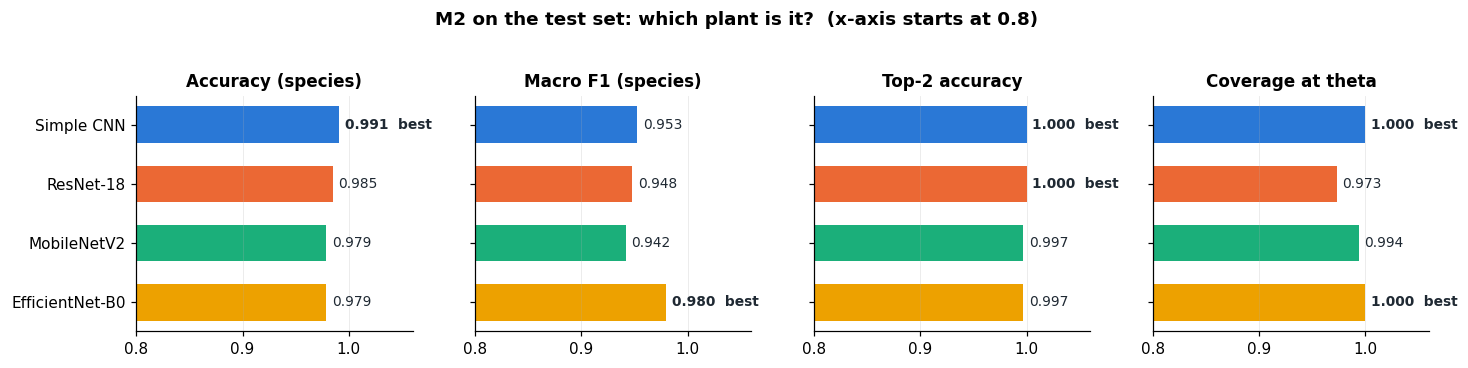

In [8]:
# =============================================================================
# FIGURE: FOUR METRICS, FOUR MODELS
# =============================================================================
panels = [("Accuracy (species)", species_table["Accuracy (species)"]),
          ("Macro F1 (species)", species_table["Macro F1 (species)"]),
          ("Top-2 accuracy", table.loc["Top-2 accuracy"]),
          ("Coverage at theta", table.loc["Coverage at theta"])]
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.2), sharey=True)
order = MODELS[::-1]
for ax, (title, series) in zip(axes, panels):
    vals = [float(series[m]) for m in order]
    best = max(vals)
    ax.barh(order, vals, color=[MODEL_COLORS[m] for m in order], height=0.62)
    for yi, v in enumerate(vals):
        ax.text(v + 0.005, yi, f"{v:.3f}" + ("  best" if np.isclose(v, best) else ""), va="center",
                fontsize=9, color=INK, fontweight="bold" if np.isclose(v, best) else "normal")
    ax.set_xlim(0.8, 1.06); ax.set_xticks([0.8, 0.9, 1.0])
    ax.set_title(title); ax.grid(axis="y", visible=False)
plt.suptitle("M2 on the test set: which plant is it?  (x-axis starts at 0.8)", fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "M2_compare_scores.png"), bbox_inches="tight")
plt.show()

## Step 4 — Are the differences real? Confidence intervals

We resample the test set **1,000 times, by leaf group** (never single photos, so
near-identical shots stay together), and re-score every model on each resample.
The 2.5th–97.5th percentiles give a **95% confidence interval**.

The second table answers the direct question: *in what share of resamples does
the leader beat each other model?* **95% or more** is a difference you can defend.
Below that, the honest word is **comparable**.

In [9]:
# =============================================================================
# GROUP BOOTSTRAP
# =============================================================================
uniq = np.unique(groups)
rows_of = {g: np.where(groups == g)[0] for g in uniq}
boot = {m: {"Accuracy": [], "Macro F1": []} for m in MODELS}
for b in range(N_BOOTSTRAP):
    idx = np.concatenate([rows_of[g] for g in rng.choice(uniq, size=len(uniq), replace=True)])
    yb = ys[idx]
    for m in MODELS:
        s = species_scores(PS[m][idx], yb)
        boot[m]["Accuracy"].append(s["accuracy"])
        boot[m]["Macro F1"].append(s["macro_f1"])
for m in MODELS:
    for k in boot[m]:
        boot[m][k] = np.array(boot[m][k])

ci = pd.DataFrame({m: {f"{k} {q}": np.percentile(boot[m][k], p)
                       for k in ["Accuracy", "Macro F1"]
                       for q, p in [("low", 2.5), ("mid", 50), ("high", 97.5)]}
                   for m in MODELS}).T
print("95% confidence intervals (species level, group bootstrap):")
print(ci.round(3).to_string())

wins = {}
for k in ["Macro F1", "Accuracy"]:
    lead = max(MODELS, key=lambda m: np.median(boot[m][k]))
    wins[k] = (lead, {m: float(np.mean(boot[lead][k] > boot[m][k])) for m in MODELS if m != lead})
    print(f"\n{k}: leader is {lead}. Share of resamples in which it beats:")
    for m, w in wins[k][1].items():
        verdict = "real difference" if w >= 0.95 else "comparable"
        print(f"   {m:<16} {w:6.1%}   -> {verdict}")

95% confidence intervals (species level, group bootstrap):
                 Accuracy low  Accuracy mid  Accuracy high  Macro F1 low  Macro F1 mid  Macro F1 high
Simple CNN              0.980         0.991          1.000         0.878         0.970          1.000
ResNet-18               0.971         0.985          0.997         0.878         0.966          0.997
MobileNetV2             0.963         0.979          0.991         0.873         0.960          0.991
EfficientNet-B0         0.961         0.979          0.994         0.961         0.979          0.994

Macro F1: leader is EfficientNet-B0. Share of resamples in which it beats:
   Simple CNN        54.7%   -> comparable
   ResNet-18         57.2%   -> comparable
   MobileNetV2       70.1%   -> comparable

Accuracy: leader is Simple CNN. Share of resamples in which it beats:
   ResNet-18         72.7%   -> comparable
   MobileNetV2       88.3%   -> comparable
   EfficientNet-B0   92.9%   -> comparable


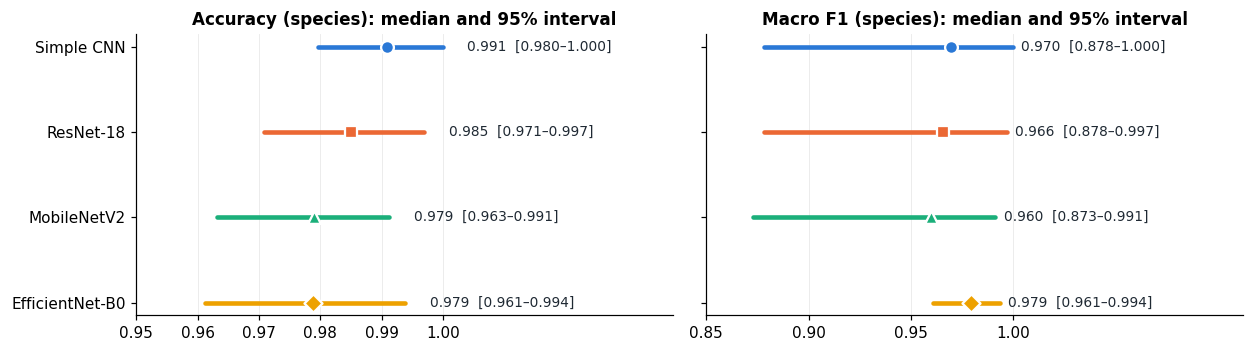

In [10]:
# =============================================================================
# FIGURE: CONFIDENCE INTERVALS
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.3), sharey=True)
for ax, k in zip(axes, ["Accuracy", "Macro F1"]):
    for yi, m in enumerate(MODELS[::-1]):
        lo, mid, hi = ci.loc[m, f"{k} low"], ci.loc[m, f"{k} mid"], ci.loc[m, f"{k} high"]
        ax.plot([lo, hi], [yi, yi], color=MODEL_COLORS[m], linewidth=3, solid_capstyle="round")
        ax.scatter([mid], [yi], color=MODEL_COLORS[m], marker=MODEL_MARKERS[m], s=70,
                   edgecolor="white", linewidth=1.5, zorder=3)
        ax.text(hi + 0.004, yi, f"{mid:.3f}  [{lo:.3f}–{hi:.3f}]", va="center", fontsize=9, color=INK)
    ax.set_yticks(range(len(MODELS)), MODELS[::-1])
    x0 = max(0.0, np.floor((ci[f"{k} low"].min() - 0.01) * 20) / 20)   # a multiple of 0.05
    ax.set_xlim(x0, 1.0 + (1.0 - x0) * 0.75)                             # room for the labels
    step = 0.05 if (1.0 - x0) > 0.12 else (0.02 if (1.0 - x0) > 0.06 else 0.01)
    ax.set_xticks(np.round(np.arange(x0, 1.0001, step), 2))              # scores stop at 1.0
    ax.set_title(f"{k} (species): median and 95% interval")
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "M2_compare_confidence.png"))
plt.show()

## Step 5 — Accuracy against size and speed

Each point is one model. Left is smaller; up is more accurate. The error bars
are the 95% intervals from Step 4. The shaded band marks models that fit in
**1 MB** after INT8 compression, which is comfortable on an ESP32-S3-class
microcontroller alongside the M1 motion model, the firmware and the camera buffers.

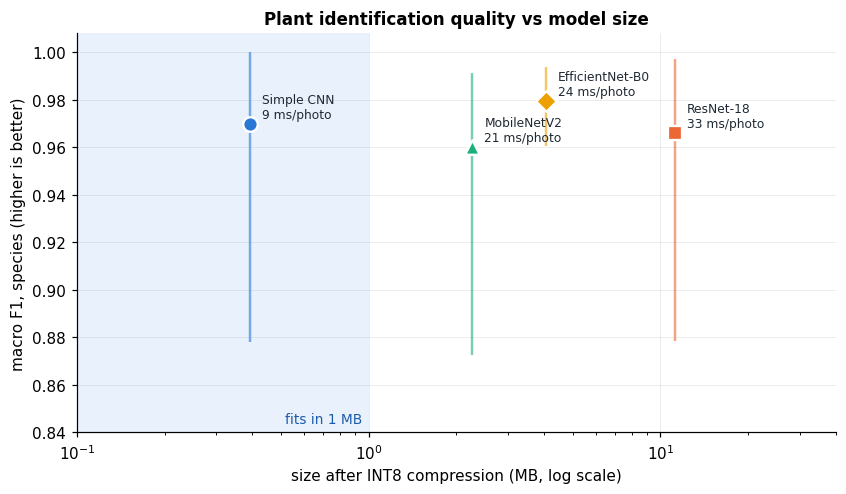

In [11]:
# =============================================================================
# FIGURE: ACCURACY vs SIZE
# =============================================================================
fig, ax = plt.subplots(figsize=(7.8, 4.6))
ax.axvspan(0.05, 1.0, color="#86b6ef", alpha=0.18, lw=0)
y_lo = np.floor((ci["Macro F1 low"].min() - 0.02) * 50) / 50
ax.text(0.95, y_lo + 0.004, "fits in 1 MB", ha="right", fontsize=9, color="#1c5cab")
for m in MODELS:
    xm, ym = R[m]["int8_estimate_mb"], ci.loc[m, "Macro F1 mid"]
    ax.errorbar(xm, ym, yerr=[[ym - ci.loc[m, "Macro F1 low"]], [ci.loc[m, "Macro F1 high"] - ym]],
                fmt="none", ecolor=MODEL_COLORS[m], elinewidth=1.6, alpha=0.6)
    ax.scatter(xm, ym, s=90, color=MODEL_COLORS[m], marker=MODEL_MARKERS[m],
               edgecolor="white", linewidth=1.5, zorder=3)
    ax.annotate(f"{m}\n{R[m]['ms_per_image']:.0f} ms/photo", (xm, ym), xytext=(8, 4),
                textcoords="offset points", fontsize=8, color=INK)
ax.set_xscale("log"); ax.set_xlim(0.1, 40); ax.set_ylim(y_lo, 1.008)
ax.set_xlabel("size after INT8 compression (MB, log scale)")
ax.set_ylabel("macro F1, species (higher is better)")
ax.set_title("Plant identification quality vs model size")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "M2_compare_tradeoff.png"))
plt.show()

## Step 6 — The selection rule, and the choice

The rule is fixed before reading the result:

1. **Best quality first.** The leader is the model with the highest median macro
   F1 on species. Macro F1 treats every plant equally, which matters for a
   heritage record where rare plants count as much as common ones.
2. **Comparable means tied.** Any model the leader does *not* beat in at least
   95% of resamples is statistically comparable to it.
3. **Among the tied, the smallest wins.** Less memory, faster decisions and less
   battery on the collar. A model that is no better but bigger has no claim.

In [12]:
# =============================================================================
# APPLY THE RULE
# =============================================================================
lead, beat = wins["Macro F1"]
tied = [lead] + [m for m, w in beat.items() if w < 0.95]
chosen = min(tied, key=lambda m: R[m]["parameters"])

print(f"Leader on macro F1 (species):   {lead}  "
      f"(median {ci.loc[lead, 'Macro F1 mid']:.3f})")
print(f"Statistically comparable to it: {', '.join(tied)}")
print(f"Clearly behind (>= 95%):        {', '.join(m for m, w in beat.items() if w >= 0.95) or 'none'}")
print()
print("=" * 72)
print(f"SELECTED FOR THE COLLAR:  {chosen}")
print(f"  macro F1 (species) {ci.loc[chosen, 'Macro F1 mid']:.3f} "
      f"[{ci.loc[chosen, 'Macro F1 low']:.3f}–{ci.loc[chosen, 'Macro F1 high']:.3f}],  "
      f"accuracy {ci.loc[chosen, 'Accuracy mid']:.3f}")
print(f"  {R[chosen]['parameters']:,} weights, {R[chosen]['int8_estimate_mb']:.2f} MB after INT8, "
      f"{R[chosen]['ms_per_image']:.1f} ms per photo")
if chosen != lead:
    print(f"  ({lead} scored highest, but not by a margin the test set can confirm, and it is "
          f"{R[lead]['parameters'] / R[chosen]['parameters']:.0f}x larger.)")
print("=" * 72)

json.dump({"selected": chosen, "leader": lead, "comparable": tied,
           "win_share_vs_leader": beat, "species": NAMES,
           "species_scores": species_table.reset_index().to_dict(orient="records")},
          open(os.path.join(RESULTS_DIR, "M2_selection.json"), "w"), indent=2, default=float)
print("Saved: M2_selection.json")

Leader on macro F1 (species):   EfficientNet-B0  (median 0.979)
Statistically comparable to it: EfficientNet-B0, Simple CNN, ResNet-18, MobileNetV2
Clearly behind (>= 95%):        none

SELECTED FOR THE COLLAR:  Simple CNN
  macro F1 (species) 0.970 [0.878–1.000],  accuracy 0.991
  391,398 weights, 0.39 MB after INT8, 9.4 ms per photo
  (EfficientNet-B0 scored highest, but not by a margin the test set can confirm, and it is 10x larger.)
Saved: M2_selection.json


---

## Discussion — what to write

Your exact numbers are in the printed output above. These are the patterns to
defend.

**1. All four models identify the plants well.** Every model reaches roughly
97–98% accuracy on photos it has never seen, from leaf groups it has never seen.
Near-identical shots were kept together, so these scores are honest.

**2. The dataset had a labelling quirk, and the merge fixes it.** Neem is stored
in two folders. The most common mistake in *every* model was one neem folder
called the other, which isn't a real error for the collar. Scoring on species
removes it. Say this plainly: it shows you checked the data, not just the model.

**3. Bigger was not better.** ResNet-18 has 28 times the weights of the Simple
CNN and did not beat it. With about 1,800 training photos, extra capacity has
nothing extra to learn. The efficient designs (MobileNetV2, EfficientNet-B0) did
no better per weight either. This matches the collar (M1) result: on small,
specific datasets, simple models hold their own.

**4. The test set is small for some plants.** A species with only a few test
photos can swing its F1 on a single photo, which is why the confidence intervals
overlap. Name this as a limitation. It's also the strongest argument for the
team's own pen-trial photos next semester.

**5. The choice.** Step 6 applies the rule. Whichever model it selects, the
argument is the same three sentences: *it is statistically as accurate as the
best model, it is the smallest of those, and small means it can actually run on
the collar.*

### Figures saved for the report (in `plant_results/figures/`)

| File | Use it for |
|---|---|
| `M2_compare_scores.png` | The headline comparison |
| `M2_compare_per_species_f1.png` | Which plants are easy and which are hard |
| `M2_compare_confusion_species.png` | What each model confuses |
| `M2_compare_confidence.png` | Whether the differences are real |
| `M2_compare_tradeoff.png` | The deployment decision |

Plus `plant_results/results/M2_species_scores.csv` and `M2_selection.json`.